# AI-Based Predictive Maintenance for Injection Molding Machines
### Supervised Learning + Feature Engineering Pipeline

**Project context.** Injection molding maintenance today is mostly reactive or
preventive: machines are fixed after they break, or serviced on a fixed
schedule regardless of actual condition. This notebook builds the machine
learning core of a predictive maintenance system: it turns raw process-sensor
readings from every molding cycle into an early-warning signal for **9 machine
subsystems**, so maintenance can happen *before* a failure stops production.

**What this notebook does, in order:**

1. Load the dataset and understand its structure.
2. Identify the 9 target (subsystem health) columns and separate them from the input features.
3. Clean the data (duplicates, timestamps, missing values, impossible values) *before* any feature engineering.
4. Drop redundant, highly-correlated sensor features.
5. Split the data **chronologically** (no shuffling — this is time-ordered process data).
6. Engineer lag/rolling "trend" features *after* the split, so no information leaks across the split boundary.
7. Separate identification / categorical / numerical columns and decide on time features.
8. Encode categorical columns appropriately per model family.
9. Train 8 candidate models **per subsystem target**, select the best one on the validation set, and report final, honest metrics on an untouched test set.

Each of the 9 targets (`Hopper_State`, `Barrel_Heater_State`, `Screw_State`,
`Injection_Unit_State`, `Hydraulic_System_State`, `Clamp_Unit_State`,
`Mold_State`, `Cooling_System_State`, `Ejector_System_State`) is a 3-class
health label. We assume the standard convention used across the dataset:

| Code | Meaning |
|---|---|
| 0 | Normal operation |
| 1 | Warning / early degradation |
| 2 | Critical condition (failure imminent) |

This is exactly the label an early-alert system needs to predict — not
accuracy on the easy majority class, but recall on the rare Warning/Critical
cycles.

## 0. Imports & global settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# --- colour system: status colours double as the 3 class colours (0/1/2 = Normal/Warning/Critical) ---
COLOR_GOOD = "#0ca30c"
COLOR_WARNING = "#fab219"
COLOR_CRITICAL = "#d03b3b"
STATE_COLORS = [COLOR_GOOD, COLOR_WARNING, COLOR_CRITICAL]
STATE_LABELS = ["0: Normal", "1: Warning", "2: Critical"]

CAT_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#2a78d6", "#f0efec", "#e34948"])
SEQUENTIAL_BLUE_CMAP = LinearSegmentedColormap.from_list("seq_blue", ["#fcfcfb", "#3987e5", "#0d366b"])

INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

print("Imports OK")
print("xgboost", xgb.__version__, "| lightgbm", lgb.__version__, "| catboost", cb.__version__, "| sklearn ok")

Imports OK
xgboost 3.2.0 | lightgbm 4.7.0 | catboost 1.2.10 | sklearn ok


## 1. Load the data and understand it

In [ ]:
df_raw = pd.read_csv("synthetic_injection_molding.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (40000, 46)


,mold_name,timestamp,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,mold_core_temp,mold_cavity_temp,inj_speed1,inj_speed2,inj_speed3,actual_inj_pressure,vp_transition,inj_time_actual,holding_pressure_stage1,holding_pressure_stage2,holding_pressure_stage3,screw_rpm,back_pressure,decompression_speed,decompression_distance,cushion_size,clamp_force,mold_close_speed,mold_protection_pressure,ejection_stroke,ejection_speed,cooling_time,mold_open_reset_time,part_weight,shot_weight,screw_diameter,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,Smart Router Enclosure,00:00.0,"ABS (Flame Retardant, Medium Flow)",180,1,45,230,225,211,201,67,70,34,57,19,120,8.9,1.33,76,53,34,76,8,14,4.8,4.0,134,248,12,48,38,14.66,3.67,34.4,86.1,45,24.61,0,0,0,0,0,0,0,0,0
1,Smart Router Enclosure,00:24.6,"ABS (Flame Retardant, Medium Flow)",180,2,44,231,225,216,198,65,72,34,55,20,119,8.5,1.38,74,52,34,75,8,16,5.1,3.8,133,248,12,47,39,14.07,3.69,34.0,85.3,45,24.13,0,0,0,0,0,0,0,0,0
2,Smart Router Enclosure,00:48.7,"ABS (Flame Retardant, Medium Flow)",180,3,45,229,225,215,200,65,71,35,58,20,121,8.6,1.37,73,54,34,76,8,14,4.9,4.1,133,236,12,46,38,14.57,3.59,34.9,82.9,45,24.49,0,0,0,0,0,0,0,0,0
3,Smart Router Enclosure,01:13.2,"ABS (Flame Retardant, Medium Flow)",180,4,45,230,224,214,203,65,71,35,60,18,118,8.6,1.34,76,56,35,74,8,15,5.2,4.0,140,241,11,47,39,14.26,3.41,33.5,84.2,45,24.06,0,0,0,0,0,0,0,0,0
4,Smart Router Enclosure,01:37.3,"ABS (Flame Retardant, Medium Flow)",180,5,45,230,224,215,202,65,69,34,58,19,117,9.0,1.35,76,53,35,74,8,14,4.8,4.1,138,253,11,43,39,13.96,3.44,33.5,79.8,45,23.63,0,0,0,0,0,0,0,0,0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   mold_name                 40000 non-null  object 
 1   timestamp                 40000 non-null  object 
 2   material_name             40000 non-null  object 
 3   machine_tonnage           40000 non-null  int64  
 4   cycle_number              40000 non-null  int64  
 5   hopper_temp               40000 non-null  int64  
 6   nozzle_temp               40000 non-null  int64  
 7   H1                        40000 non-null  int64  
 8   H2                        40000 non-null  int64  
 9   H3                        40000 non-null  int64  
 10  mold_core_temp            40000 non-null  int64  
 11  mold_cavity_temp          40000 non-null  int64  
 12  inj_speed1                40000 non-null  int64  
 13  inj_speed2                40000 non-null  int64  
 14  inj_sp

In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_tonnage,40000.0,282.500000,80.118103,180.00,232.5000,275.000,325.0000,400.00
cycle_number,40000.0,5000.500000,2886.787417,1.00,2500.7500,5000.500,7500.2500,10000.00
hopper_temp,40000.0,46.036250,9.244616,27.00,36.0000,46.000,54.0000,66.00
nozzle_temp,40000.0,260.923675,27.554740,221.00,233.0000,261.000,288.0000,293.00
H1,40000.0,256.888150,26.901231,214.00,229.0000,258.500,283.0000,288.00
H2,40000.0,246.436200,28.986350,202.00,216.0000,245.000,275.0000,285.00
H3,40000.0,233.363725,31.483981,184.00,201.0000,231.000,265.0000,275.00
mold_core_temp,40000.0,69.586225,35.416674,12.00,51.0000,80.000,98.0000,124.00
mold_cavity_temp,40000.0,75.700275,37.085925,14.00,55.7500,87.500,106.0000,130.00
inj_speed1,40000.0,125.356525,171.691305,13.00,21.0000,30.000,100.2500,498.00


In [5]:
# The 9 target columns: one health-state label per machine subsystem.
TARGET_COLS = [
    "Hopper_State", "Barrel_Heater_State", "Screw_State", "Injection_Unit_State",
    "Hydraulic_System_State", "Clamp_Unit_State", "Mold_State",
    "Cooling_System_State", "Ejector_System_State",
]

# Columns that identify *what produced the row* rather than describe the process itself.
# (mold_name is also a genuinely useful predictor -- different machines behave differently --
#  so it is kept for traceability here AND used later as a categorical feature.)
ID_COLS = ["mold_name", "timestamp", "cycle_number"]

FEATURE_COLS_RAW = [c for c in df_raw.columns if c not in TARGET_COLS + ID_COLS]

print(f"{len(TARGET_COLS)} target columns:", TARGET_COLS)
print(f"{len(ID_COLS)} identification columns:", ID_COLS)
print(f"{len(FEATURE_COLS_RAW)} raw candidate feature columns:", FEATURE_COLS_RAW)

print("\nmold_name values:", df_raw.mold_name.unique().tolist())
print("material_name values:", df_raw.material_name.unique().tolist())
print("\nRows per mold:")
print(df_raw.mold_name.value_counts())

9 target columns: ['Hopper_State', 'Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State', 'Hydraulic_System_State', 'Clamp_Unit_State', 'Mold_State', 'Cooling_System_State', 'Ejector_System_State']
3 identification columns: ['mold_name', 'timestamp', 'cycle_number']
34 raw candidate feature columns: ['material_name', 'machine_tonnage', 'hopper_temp', 'nozzle_temp', 'H1', 'H2', 'H3', 'mold_core_temp', 'mold_cavity_temp', 'inj_speed1', 'inj_speed2', 'inj_speed3', 'actual_inj_pressure', 'vp_transition', 'inj_time_actual', 'holding_pressure_stage1', 'holding_pressure_stage2', 'holding_pressure_stage3', 'screw_rpm', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_size', 'clamp_force', 'mold_close_speed', 'mold_protection_pressure', 'ejection_stroke', 'ejection_speed', 'cooling_time', 'mold_open_reset_time', 'part_weight', 'shot_weight', 'screw_diameter', 'total_cycle_time']

mold_name values: ['Smart Router Enclosure', 'Blood Filtration Housing', 'Rectangul

**Understanding the target columns.** Each `*_State` column is a per-cycle
health label for one subsystem. A machine's subsystems can degrade
independently (the barrel heater can be fine while the screw is wearing out),
so this is naturally **9 separate 3-class classification problems** that
share the same input features — not one combined multi-label problem. The
pipeline below is written once as reusable functions and looped over all 9
targets later in the notebook.

Let's look at how imbalanced each target is — this drives the evaluation
metric choice later (macro F1 / balanced accuracy, not raw accuracy).

In [6]:
class_counts = pd.DataFrame({t: df_raw[t].value_counts().reindex([0, 1, 2]) for t in TARGET_COLS}).T
class_pct = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
summary = class_counts.astype("Int64").astype(str) + " (" + class_pct.round(1).astype(str) + "%)"
summary.columns = STATE_LABELS
summary

,0: Normal,1: Warning,2: Critical
Hopper_State,29970 (74.9%),8563 (21.4%),1467 (3.7%)
Barrel_Heater_State,32661 (81.7%),6258 (15.6%),1081 (2.7%)
Screw_State,32781 (82.0%),6003 (15.0%),1216 (3.0%)
Injection_Unit_State,32785 (82.0%),5624 (14.1%),1591 (4.0%)
Hydraulic_System_State,33214 (83.0%),5194 (13.0%),1592 (4.0%)
Clamp_Unit_State,33633 (84.1%),5197 (13.0%),1170 (2.9%)
Mold_State,31961 (79.9%),7010 (17.5%),1029 (2.6%)
Cooling_System_State,32518 (81.3%),5685 (14.2%),1797 (4.5%)
Ejector_System_State,31405 (78.5%),6854 (17.1%),1741 (4.4%)


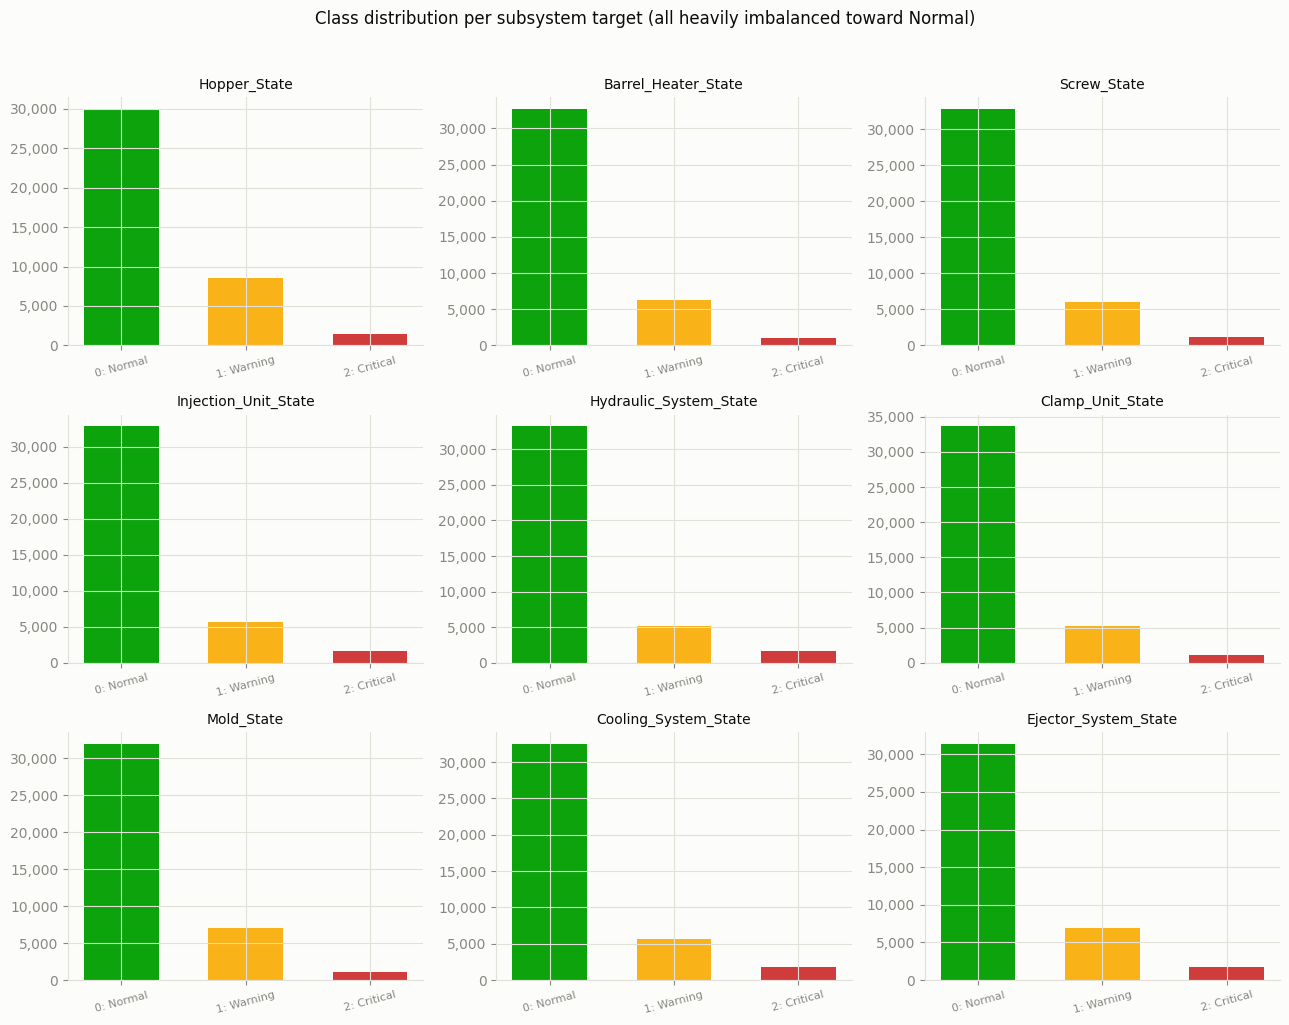

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, t in zip(axes.flat, TARGET_COLS):
    counts = df_raw[t].value_counts().reindex([0, 1, 2]).fillna(0)
    ax.bar(STATE_LABELS, counts.values, color=STATE_COLORS, width=0.6)
    ax.set_title(t, fontsize=10, color=INK)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
fig.suptitle("Class distribution per subsystem target (all heavily imbalanced toward Normal)", y=1.02)
fig.tight_layout()
plt.show()

Every target is dominated by class 0 (Normal) at roughly 75-85% of rows, with
class 2 (Critical) making up only 2.5-4.5%. **A model that always predicts
"Normal" would already score 75-85% accuracy while never once catching a real
problem.** This is exactly why accuracy alone is the wrong metric here —
macro F1 and balanced accuracy (used from the modeling section onward) weight
the rare Warning/Critical classes as much as the common Normal class.

## 2. Clean the data (before any feature engineering)

Cleaning happens in a fixed, deliberate order, all *before* engineering any
new features:

1. Remove duplicate rows.
2. Convert `timestamp` to a real datetime and sort by it.
3. Check for missing values.
4. Check for physically impossible values (negative pressure, temperature, time, weight, etc.).
5. Check whether the target labels themselves contain missing values, and drop rows with a missing *selected* target.
6. Re-inspect the per-class sample counts (already done above).

We deliberately do **not** remove extreme-but-valid values (e.g. an unusually
high pressure or temperature) — those extremes are often exactly the signal
that a subsystem is starting to fail, which is the entire point of this
project.

In [8]:
# --- 2.1 remove duplicate rows ---
n_before = len(df_raw)
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_before - len(df_clean)} duplicate rows -> {len(df_clean)} rows remain.")

Removed 0 duplicate rows -> 40000 rows remain.


**2.2 Converting `timestamp`.** The raw `timestamp` column looks like
`"16:21.7"` — a `MM:SS.s` clock, with **no date and no hour**. Inspecting it
shows the clock wraps back to `00:00` roughly every 60 minutes and resets
again at the start of every mold's block of rows, so it is not a globally
monotonic datetime on its own. What *is* reliable is `cycle_number`, which
counts 1..10,000 in strict production order within each `mold_name`.

So we reconstruct a proper monotonic datetime per mold by "unwrapping" the
60-minute clock (adding an hour every time it rolls over) and anchoring it to
an arbitrary reference date — this gives us a real `datetime` column and lets
us sort correctly, without inventing information the raw data doesn't have.

In [9]:
def parse_mmss_to_seconds(s):
    mm, ss = s.split(":")
    return int(mm) * 60 + float(ss)

def unwrap_seconds(sec_series):
    sec = sec_series.to_numpy()
    diffs = np.diff(sec)
    wrap_jump = np.where(diffs < -1.0, 3600.0, 0.0)          # clock rolled over 60 min -> add an hour
    offset = np.concatenate([[0.0], np.cumsum(wrap_jump)])
    return pd.Series(sec + offset, index=sec_series.index)

# sort by [mold_name, cycle_number] first -- this IS the true chronological order per machine
df_clean = df_clean.sort_values(["mold_name", "cycle_number"]).reset_index(drop=True)

df_clean["_raw_sec"] = df_clean["timestamp"].apply(parse_mmss_to_seconds)
df_clean["elapsed_seconds"] = df_clean.groupby("mold_name")["_raw_sec"].transform(unwrap_seconds)
df_clean["datetime"] = pd.Timestamp("2026-01-01") + pd.to_timedelta(df_clean["elapsed_seconds"], unit="s")
df_clean = df_clean.drop(columns="_raw_sec")

# sanity check: datetime must be strictly increasing within every mold
monotonic_ok = df_clean.groupby("mold_name")["datetime"].apply(lambda s: s.is_monotonic_increasing).all()
print("datetime strictly increasing within every mold:", monotonic_ok)
df_clean[["mold_name", "cycle_number", "timestamp", "datetime"]].head()

datetime strictly increasing within every mold: True


,mold_name,cycle_number,timestamp,datetime
0,Blood Filtration Housing,1,21:41.1,2026-01-01 00:21:41.100
1,Blood Filtration Housing,2,22:12.8,2026-01-01 00:22:12.800
2,Blood Filtration Housing,3,22:44.4,2026-01-01 00:22:44.400
3,Blood Filtration Housing,4,23:16.2,2026-01-01 00:23:16.200
4,Blood Filtration Housing,5,23:47.6,2026-01-01 00:23:47.600


In [10]:
# --- 2.3 missing values in the feature columns ---
missing = df_clean[FEATURE_COLS_RAW].isnull().sum()
missing = missing[missing > 0]
print("Feature columns with missing values:" if len(missing) else "No missing values in any feature column.")
if len(missing):
    print(missing)

No missing values in any feature column.


In [11]:
# --- 2.4 impossible values: nothing in this process (pressure, temperature*, time, weight,
#     speed, distance...) can physically be negative. *Temperature is in Celsius so a negative
#     reading is still an out-of-range sensor error for this process, not a valid extreme.
impossible = {}
for c in FEATURE_COLS_RAW:
    if pd.api.types.is_numeric_dtype(df_clean[c]):
        mn = df_clean[c].min()
        if mn < 0:
            impossible[c] = mn

if impossible:
    print("Impossible (negative) values found:")
    for k, v in impossible.items():
        print(f"  {k}: min = {v}")
else:
    print("No impossible negative values found in any numeric process column.")

print("\ncycle_number always >= 1:", (df_clean["cycle_number"] >= 1).all())

No impossible negative values found in any numeric process column.

cycle_number always >= 1: True


In [12]:
# --- 2.5 missing target labels ---
print("Missing values per target column:")
print(df_clean[TARGET_COLS].isnull().sum())

# None are missing right now, but we still apply the rule defensively: rows with a
# missing value in the *currently selected* target are dropped just before that
# target's train/val/test split is built (see `run_pipeline_for_target` below),
# rather than here -- dropping globally now would discard rows that are perfectly
# usable for the other 8 targets.
print("\n(No rows dropped here -- per-target NaN removal happens inside the modeling loop.)")

Missing values per target column:
Hopper_State              0
Barrel_Heater_State       0
Screw_State               0
Injection_Unit_State      0
Hydraulic_System_State    0
Clamp_Unit_State          0
Mold_State                0
Cooling_System_State      0
Ejector_System_State      0
dtype: int64

(No rows dropped here -- per-target NaN removal happens inside the modeling loop.)


**2.6 Per-class sample counts** were already inspected in Section 1 (identical
here since zero duplicate rows were removed). Every target has a usable
number of samples in its smallest class (>1,000 rows even for the rarest
Critical class), which is enough for a 70/15/15 split to still leave a few
hundred examples of the rare classes in validation and test.

## 3. Drop redundant, highly-correlated features

Injection molding process parameters are physically linked (e.g. the three
zone-heater temperatures move together, the three holding-pressure stages
move together), so several raw sensor columns are near-duplicates of each
other. Feeding both copies into a model adds noise and — for Logistic
Regression especially — multicollinearity, without adding information.

We compute the correlation matrix of the numeric feature columns, then
greedily drop one column from every pair with `|correlation| > 0.95`,
keeping the first-encountered (left-most) column of each redundant group.

**Important ordering note:** this analysis identifies *which raw,
contemporaneous columns are redundant*, but we don't remove them from the
dataframe yet — Section 6 derives lag/rolling ("previous cycle", "rolling
mean") features from some of these same raw columns (e.g. `shot_weight`,
`total_cycle_time`) *after* the train/val/test split. The redundant raw
columns are only dropped from the final modeling feature list in Section 7,
once every lag/rolling feature has already been derived from them. A raw
value and its lagged version are different pieces of information (the
lagged version captures *drift/trend*, not just level) even when today's raw
readings are collinear with each other.

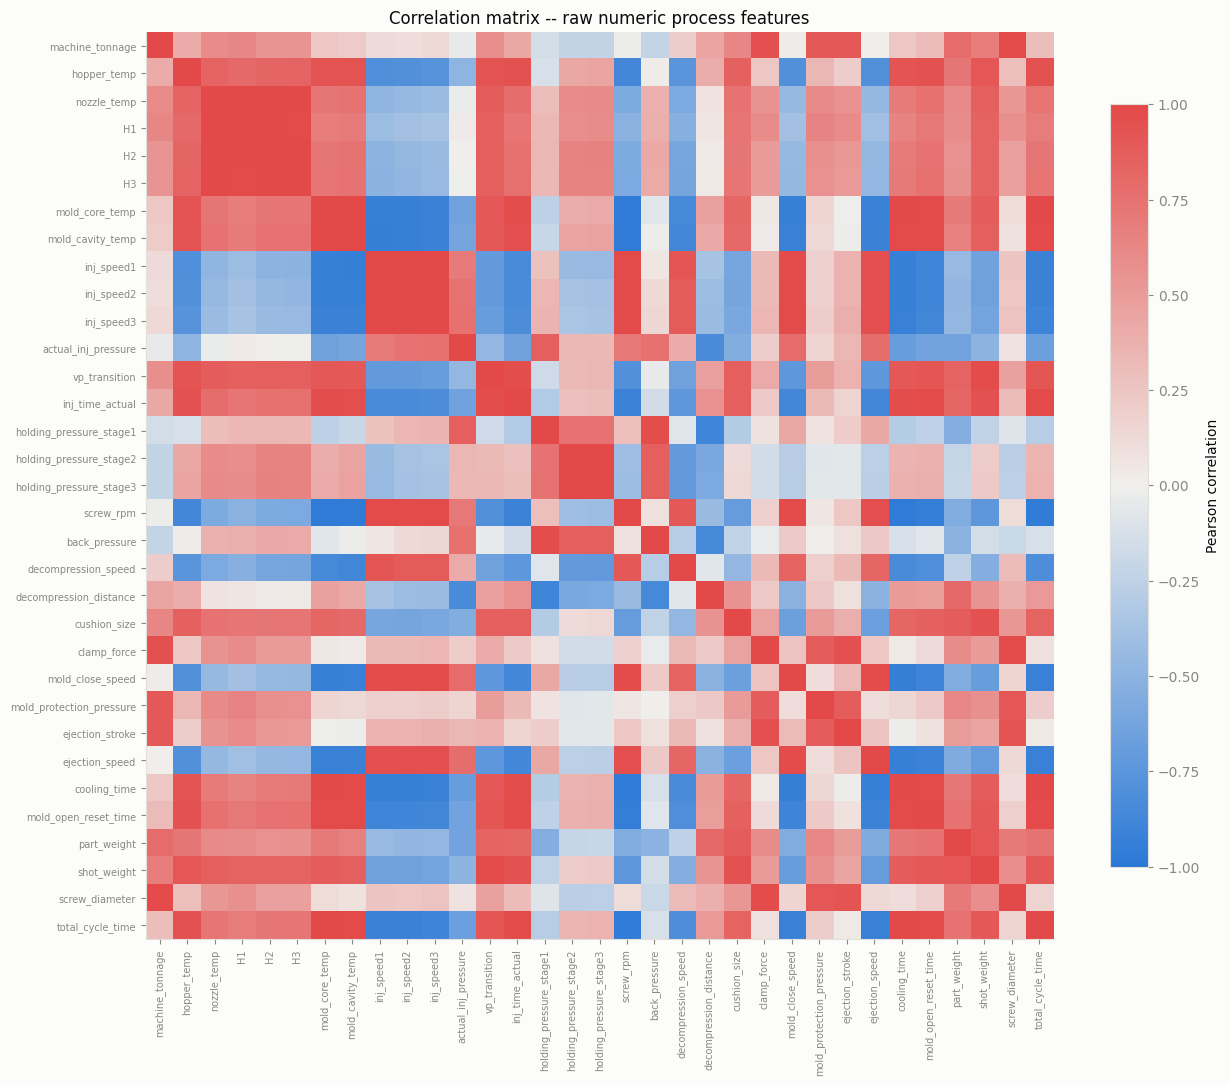

In [13]:
num_cols_for_corr = df_clean[FEATURE_COLS_RAW].select_dtypes(include="number").columns.tolist()
corr = df_clean[num_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols_for_corr))); ax.set_xticklabels(num_cols_for_corr, rotation=90, fontsize=7)
ax.set_yticks(range(len(num_cols_for_corr))); ax.set_yticklabels(num_cols_for_corr, fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation matrix -- raw numeric process features")
fig.tight_layout()
plt.show()

In [14]:
def greedy_correlation_drop(corr_df, threshold=0.95):
    cols = corr_df.columns.tolist()
    abs_corr = corr_df.abs()
    dropped, reasons = set(), {}
    for i, c1 in enumerate(cols):
        if c1 in dropped:
            continue
        for c2 in cols[i + 1:]:
            if c2 in dropped:
                continue
            if abs_corr.loc[c1, c2] > threshold:
                dropped.add(c2)
                reasons[c2] = (c1, abs_corr.loc[c1, c2])
    return dropped, reasons

CORR_THRESHOLD = 0.95
dropped_corr_cols, drop_reasons = greedy_correlation_drop(corr, CORR_THRESHOLD)

print(f"Dropping {len(dropped_corr_cols)} of {len(num_cols_for_corr)} numeric columns "
      f"(|correlation| > {CORR_THRESHOLD} with a column already kept):\n")
for c, (kept_because_of, r) in sorted(drop_reasons.items()):
    print(f"  drop {c:<28s} <-> {kept_because_of:<24s} (r = {r:.3f})")

KEPT_NUMERIC_BASE = [c for c in num_cols_for_corr if c not in dropped_corr_cols]
print(f"\n{len(KEPT_NUMERIC_BASE)} base numeric columns kept:")
print(KEPT_NUMERIC_BASE)

Dropping 18 of 33 numeric columns (|correlation| > 0.95 with a column already kept):

  drop H1                           <-> nozzle_temp              (r = 0.996)
  drop H2                           <-> nozzle_temp              (r = 0.996)
  drop H3                           <-> nozzle_temp              (r = 0.996)
  drop back_pressure                <-> holding_pressure_stage1  (r = 0.966)
  drop clamp_force                  <-> machine_tonnage          (r = 0.950)
  drop cooling_time                 <-> mold_core_temp           (r = 0.996)
  drop ejection_speed               <-> inj_speed1               (r = 0.952)
  drop holding_pressure_stage3      <-> holding_pressure_stage2  (r = 0.999)
  drop inj_speed2                   <-> inj_speed1               (r = 0.995)
  drop inj_speed3                   <-> inj_speed1               (r = 0.994)
  drop inj_time_actual              <-> mold_core_temp           (r = 0.968)
  drop mold_cavity_temp             <-> mold_core_temp           (r

## 4. Split the data chronologically (70% / 15% / 15%)

This is time/cycle-ordered process data, so a random shuffled split would let
the model "peek" at cycles that happen right after (or before) the ones it's
tested on — an unrealistic advantage a real deployed model would never have.
We use a **chronological split**: the first 70% of cycles train, the next
15% validate, the last 15% test.

Because the dataset in fact holds **4 independent machines** (`mold_name`),
a single global chronological cut would put entire machines only in train
(the CSV is grouped mold-by-mold) and leave the test set with just one
machine's tail end — the model would never even be evaluated on 3 of the 4
machines. Instead we apply the 70/15/15 chronological cut **within each
mold's own cycle sequence**, then recombine. This keeps every split
time-ordered *and* keeps all 4 machines represented in train, validation and
test — the realistic scenario for a system meant to monitor multiple
machines going forward in time.

In [15]:
def chronological_split_by_group(df, group_col="mold_name", order_col="cycle_number",
                                  train_frac=0.70, val_frac=0.15):
    train_parts, val_parts, test_parts = [], [], []
    for _, g in df.groupby(group_col, sort=False):
        g = g.sort_values(order_col)
        n = len(g)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        train_parts.append(g.iloc[:n_train])
        val_parts.append(g.iloc[n_train:n_train + n_val])
        test_parts.append(g.iloc[n_train + n_val:])
    train_df = pd.concat(train_parts).sort_values([group_col, order_col]).reset_index(drop=True)
    val_df = pd.concat(val_parts).sort_values([group_col, order_col]).reset_index(drop=True)
    test_df = pd.concat(test_parts).sort_values([group_col, order_col]).reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = chronological_split_by_group(df_clean)

print(f"train: {len(train_df):>6,} rows ({len(train_df)/len(df_clean):.1%})")
print(f"val:   {len(val_df):>6,} rows ({len(val_df)/len(df_clean):.1%})")
print(f"test:  {len(test_df):>6,} rows ({len(test_df)/len(df_clean):.1%})")

print("\nEvery machine present in every split:")
print(pd.DataFrame({
    "train": train_df.mold_name.value_counts(),
    "val": val_df.mold_name.value_counts(),
    "test": test_df.mold_name.value_counts(),
}))

# sanity check: within each mold, train cycles < val cycles < test cycles (strictly chronological)
for name in df_clean.mold_name.unique():
    tr_max = train_df.loc[train_df.mold_name == name, "cycle_number"].max()
    va_min = val_df.loc[val_df.mold_name == name, "cycle_number"].min()
    va_max = val_df.loc[val_df.mold_name == name, "cycle_number"].max()
    te_min = test_df.loc[test_df.mold_name == name, "cycle_number"].min()
    assert tr_max < va_min and va_max < te_min, f"chronology broken for {name}"
print("Chronology verified for every machine (train < val < test cycle numbers).")

train: 28,000 rows (70.0%)
val:    6,000 rows (15.0%)
test:   6,000 rows (15.0%)

Every machine present in every split:


                            train   val  test
mold_name                                    
Blood Filtration Housing     7000  1500  1500
Engine Mount Bracket         7000  1500  1500
Rectangular Food Container   7000  1500  1500
Smart Router Enclosure       7000  1500  1500
Chronology verified for every machine (train < val < test cycle numbers).


## 5. Lag & rolling ('trend') features -- created *after* the split

Predictive maintenance is fundamentally about **drift over recent cycles**,
not just the value of a single cycle in isolation. A shot weight that is
merely high isn't as informative as a shot weight that just jumped from the
previous cycle, or a pressure reading that has become unusually unstable over
the last few cycles. We add:

- `previous_cycle_shot_weight`, `previous_cycle_pressure`, `previous_cycle_cushion_size` — 1-cycle lag ("what changed since last shot").
- `rolling_mean_temperature`, `rolling_mean_clamp_force` — 5-cycle rolling mean ("recent trend level").
- `rolling_std_pressure`, `rolling_std_cycle_time` — 5-cycle rolling std ("recent process stability").

These are computed **independently inside `train_df`, `val_df` and `test_df`,
after the split**, grouped by `mold_name` and ordered by `cycle_number`. This
is deliberately stricter than computing them once on the full timeline before
splitting: it guarantees zero information ever crosses a split boundary (not
even "yesterday's" value from the train set leaking into tomorrow's row in
validation). The cost is that the first 1-4 cycles of every mold in every
split have no history yet (`NaN`) — those get median-imputed later like any
other missing value, which affects a negligible number of rows (4 molds x a
few rows out of tens of thousands).

In [16]:
LAG_WINDOW = 5

def add_lag_rolling_features(df, window=LAG_WINDOW):
    df = df.sort_values(["mold_name", "cycle_number"]).copy()
    g = df.groupby("mold_name")

    df["previous_cycle_shot_weight"] = g["shot_weight"].shift(1)
    df["previous_cycle_pressure"] = g["actual_inj_pressure"].shift(1)
    df["previous_cycle_cushion_size"] = g["cushion_size"].shift(1)

    df["rolling_mean_temperature"] = g["nozzle_temp"].transform(lambda s: s.rolling(window, min_periods=1).mean())
    df["rolling_mean_clamp_force"] = g["clamp_force"].transform(lambda s: s.rolling(window, min_periods=1).mean())

    df["rolling_std_pressure"] = g["actual_inj_pressure"].transform(lambda s: s.rolling(window, min_periods=1).std())
    df["rolling_std_cycle_time"] = g["total_cycle_time"].transform(lambda s: s.rolling(window, min_periods=1).std())
    # a rolling std needs >= 2 observations; the very first cycle of each mold has none yet -> 0 (no observed variation yet)
    df["rolling_std_pressure"] = df["rolling_std_pressure"].fillna(0)
    df["rolling_std_cycle_time"] = df["rolling_std_cycle_time"].fillna(0)
    return df

LAG_FEATURES = [
    "previous_cycle_shot_weight", "previous_cycle_pressure", "previous_cycle_cushion_size",
    "rolling_mean_temperature", "rolling_mean_clamp_force",
    "rolling_std_pressure", "rolling_std_cycle_time",
]

train_df = add_lag_rolling_features(train_df)
val_df = add_lag_rolling_features(val_df)
test_df = add_lag_rolling_features(test_df)

print("New lag/rolling columns:", LAG_FEATURES)
print("\nRows with at least one NaN lag feature (first cycle(s) of each mold per split):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_nan = d[LAG_FEATURES].isnull().any(axis=1).sum()
    print(f"  {name}: {n_nan} / {len(d)} rows ({n_nan/len(d):.2%})")

train_df[["mold_name", "cycle_number", "shot_weight", "previous_cycle_shot_weight",
          "actual_inj_pressure", "rolling_std_pressure"]].head(3)

New lag/rolling columns: ['previous_cycle_shot_weight', 'previous_cycle_pressure', 'previous_cycle_cushion_size', 'rolling_mean_temperature', 'rolling_mean_clamp_force', 'rolling_std_pressure', 'rolling_std_cycle_time']

Rows with at least one NaN lag feature (first cycle(s) of each mold per split):
  train: 4 / 28000 rows (0.01%)
  val: 4 / 6000 rows (0.07%)
  test: 4 / 6000 rows (0.07%)


,mold_name,cycle_number,shot_weight,previous_cycle_shot_weight,actual_inj_pressure,rolling_std_pressure
0,Blood Filtration Housing,1,138.6,NaN,1529,0.000000
1,Blood Filtration Housing,2,136.6,138.6,1426,72.831998
2,Blood Filtration Housing,3,140.4,136.6,1482,51.565492


## 6. Separate identification / categorical / numerical columns

- **Identification columns** (`mold_name`, `timestamp`, `datetime`, `cycle_number`) describe
  *where the row came from*, kept alongside the data for traceability and grouping/sorting.
  `mold_name` doubles as a real predictive feature too (see below).
- **Categorical features**: `mold_name`, `material_name`.
- **Numerical features**: the process-sensor readings kept after correlation
  filtering, plus the 7 new lag/rolling features, plus `cycle_number`.

**On `cycle_number`:** the instructions are to use it as a feature only if it
represents a genuine sequence rather than an arbitrary ID. Here it clearly
does — it counts a machine's shots from 1 to 10,000 in strict production
order, i.e. it is a direct proxy for **wear/age accumulated since the
machine was last serviced**, a textbook predictive-maintenance feature. So we
promote it from "ID-only" into the numeric feature list, while still using it
for sorting/grouping as an ID column too.

**On the redundant raw columns from Section 3:** they are dropped from the
feature list *now*, after being used to derive the lag/rolling features.

In [17]:
ID_COLS_FINAL = ["mold_name", "timestamp", "datetime", "cycle_number"]
CATEGORICAL_FEATURES = ["mold_name", "material_name"]

NUMERIC_FEATURES = [c for c in KEPT_NUMERIC_BASE if c not in CATEGORICAL_FEATURES]
NUMERIC_FEATURES += ["cycle_number"] + LAG_FEATURES
NUMERIC_FEATURES = list(dict.fromkeys(NUMERIC_FEATURES))  # de-duplicate, keep order

ALL_MODEL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

print(f"Categorical features ({len(CATEGORICAL_FEATURES)}):", CATEGORICAL_FEATURES)
print(f"\nNumerical features ({len(NUMERIC_FEATURES)}):", NUMERIC_FEATURES)
print(f"\nTotal model input features: {len(ALL_MODEL_FEATURES)}")
assert not (set(ALL_MODEL_FEATURES) & set(TARGET_COLS)), "a target column leaked into the feature list!"

Categorical features (2): ['mold_name', 'material_name']

Numerical features (23): ['machine_tonnage', 'hopper_temp', 'nozzle_temp', 'mold_core_temp', 'inj_speed1', 'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage1', 'holding_pressure_stage2', 'decompression_speed', 'decompression_distance', 'cushion_size', 'mold_protection_pressure', 'ejection_stroke', 'part_weight', 'cycle_number', 'previous_cycle_shot_weight', 'previous_cycle_pressure', 'previous_cycle_cushion_size', 'rolling_mean_temperature', 'rolling_mean_clamp_force', 'rolling_std_pressure', 'rolling_std_cycle_time']

Total model input features: 25


## 7. Time features -- evaluated, and skipped

The instructions call for extracting `hour`, `dayofweek`, `month` (optionally
as cyclic sin/cos features) **only if useful**. As established in Section 2,
`timestamp` here is a bare `MM:SS` clock with no real calendar information —
our reconstructed `datetime` is anchored to one arbitrary reference date
purely to make sorting/lag calculations well-defined, not because the data
contains real calendar structure. We confirm that empirically below, then
skip creating calendar time features: they would be constant or meaningless,
and would risk misleading the model with fake signal. `cycle_number` (and the
lag/rolling features already built from it) is the correct and sufficient
"time" signal for this dataset.

In [18]:
print("Distinct calendar dates across the whole (reconstructed) dataset:", df_clean["datetime"].dt.date.nunique())
print("Distinct hours-of-day represented:", sorted(df_clean["datetime"].dt.hour.unique()))
print("=> confirms hour/dayofweek/month would carry no real information here -- skipped.")

Distinct calendar dates across the whole (reconstructed) dataset: 5
Distinct hours-of-day represented: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
=> confirms hour/dayofweek/month would carry no real information here -- skipped.


## 8. Encode categorical columns

Two encoding strategies are used, matched to what each model family handles best:

- **One-hot encoding** for `material_name` / `mold_name`, used by every model
  without native categorical support: Dummy, Logistic Regression, Decision
  Tree, Random Forest, Gradient Boosting, XGBoost. Logistic Regression's
  numeric inputs are additionally standard-scaled (the only model here that's
  scale-sensitive; the tree-based models are not).
- **Native categorical handling** for LightGBM and CatBoost — both accept
  categorical columns directly and learn splits on them without exploding the
  feature space into dummy columns, which tends to work at least as well and
  is simpler.

Missing numeric values (from the lag-feature warm-up rows) are median-imputed
using **statistics fit on the training split only**, then applied unchanged
to validation and test — this avoids any leakage of validation/test
distribution information into the model.

In [19]:
def build_ohe_matrices(train_df, val_df, test_df, numeric_features, categorical_features, scale_numeric):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])
    X_train = preprocessor.fit_transform(train_df[numeric_features + categorical_features])
    X_val = preprocessor.transform(val_df[numeric_features + categorical_features])
    X_test = preprocessor.transform(test_df[numeric_features + categorical_features])
    return X_train, X_val, X_test, preprocessor


def build_native_matrices(train_df, val_df, test_df, numeric_features, categorical_features):
    # Numeric: median-imputed (fit on train only). Categorical: pandas 'category' dtype,
    # with categories fixed from the training split so val/test encode consistently.
    imputer = SimpleImputer(strategy="median")
    imputer.fit(train_df[numeric_features])

    def _prep(df):
        out = df[numeric_features + categorical_features].copy()
        out[numeric_features] = imputer.transform(out[numeric_features])
        return out

    X_train, X_val, X_test = _prep(train_df), _prep(val_df), _prep(test_df)
    for c in categorical_features:
        cat_dtype = pd.CategoricalDtype(categories=sorted(X_train[c].unique()))
        X_train[c] = X_train[c].astype(cat_dtype)
        X_val[c] = X_val[c].astype(cat_dtype)
        X_test[c] = X_test[c].astype(cat_dtype)
    return X_train, X_val, X_test

print("Encoding helper functions defined: build_ohe_matrices(), build_native_matrices()")

Encoding helper functions defined: build_ohe_matrices(), build_native_matrices()


## 9. Model training & evaluation pipeline

For **each** of the 9 targets we train the same 8 models, compare them on
the validation set, pick the best one, and score that one model exactly once
on the test set:

1. Dummy baseline (always predicts the majority class — the floor any real model must beat)
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. Gradient Boosting (scikit-learn)
6. XGBoost
7. LightGBM
8. CatBoost

Because every target is imbalanced (Section 1), every model is fit with
**balanced sample weights** (`sklearn.utils.class_weight.compute_sample_weight`)
so the rare Warning/Critical cycles are not simply ignored in favor of the
easy Normal majority.

**Model selection rule:** rank candidates on the *validation* set by macro F1
first, balanced accuracy as the tiebreaker. The test set is touched exactly
once, after the choice is already locked in, purely to report an honest,
unbiased final number.

In [20]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def plot_confusion_matrix(cm, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.3, 3.9))
    ax.imshow(cm, cmap=SEQUENTIAL_BLUE_CMAP)
    ax.set_xticks(range(cm.shape[1])); ax.set_xticklabels(STATE_LABELS[:cm.shape[1]], rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(cm.shape[0])); ax.set_yticklabels(STATE_LABELS[:cm.shape[0]], fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=10)
    thresh = cm.max() / 2 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "#ffffff" if cm[i, j] > thresh else INK
            ax.text(j, i, format(cm[i, j], ","), ha="center", va="center", color=color, fontsize=9)
    ax.grid(False)
    return ax


def get_fresh_models(random_state=RANDOM_STATE):
    # A brand-new, unfit set of the 8 candidate estimators. Must be re-created for every
    # target so no fitted state leaks between the 9 independent classification problems.
    return {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=random_state),
        "DecisionTree": DecisionTreeClassifier(max_depth=10, random_state=random_state),
        "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=random_state),
        "GradientBoosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=random_state),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=random_state, n_jobs=-1, verbosity=0,
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.1, random_state=random_state, n_jobs=-1, verbose=-1,
        ),
        "CatBoost": cb.CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.1,
            random_state=random_state, verbose=False,
        ),
    }

# models that use the one-hot / scaled matrices vs. the native-categorical matrices
OHE_MODELS = ["Dummy", "LogisticRegression", "DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"]
NATIVE_MODELS = ["LightGBM", "CatBoost"]

print("Reusable modeling functions defined.")

Reusable modeling functions defined.


In [21]:
def run_pipeline_for_target(target_col, train_df, val_df, test_df,
                             numeric_features=NUMERIC_FEATURES,
                             categorical_features=CATEGORICAL_FEATURES,
                             verbose=True):
    # --- drop rows with a missing value in *this* target (defensive; none exist today) ---
    tr = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    va = val_df.dropna(subset=[target_col]).reset_index(drop=True)
    te = test_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_train, y_val, y_test = tr[target_col].astype(int), va[target_col].astype(int), te[target_col].astype(int)

    # --- build both feature-matrix flavors ---
    Xtr_ohe, Xva_ohe, Xte_ohe, _ = build_ohe_matrices(tr, va, te, numeric_features, categorical_features, scale_numeric=False)
    Xtr_ohe_s, Xva_ohe_s, Xte_ohe_s, _ = build_ohe_matrices(tr, va, te, numeric_features, categorical_features, scale_numeric=True)
    Xtr_nat, Xva_nat, Xte_nat = build_native_matrices(tr, va, te, numeric_features, categorical_features)
    cat_idx = [len(numeric_features) + i for i in range(len(categorical_features))]

    sample_weight = compute_sample_weight("balanced", y_train)

    models = get_fresh_models()
    fitted, val_metrics = {}, {}

    for name, model in models.items():
        if name == "LogisticRegression":
            model.fit(Xtr_ohe_s, y_train, sample_weight=sample_weight)
            y_val_pred = model.predict(Xva_ohe_s)
        elif name == "Dummy":
            model.fit(Xtr_ohe, y_train)
            y_val_pred = model.predict(Xva_ohe)
        elif name in ("DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"):
            model.fit(Xtr_ohe, y_train, sample_weight=sample_weight)
            y_val_pred = model.predict(Xva_ohe)
        elif name == "LightGBM":
            model.fit(Xtr_nat, y_train, sample_weight=sample_weight, categorical_feature=categorical_features)
            y_val_pred = model.predict(Xva_nat)
        elif name == "CatBoost":
            model.set_params(cat_features=cat_idx)
            model.fit(Xtr_nat, y_train, sample_weight=sample_weight)
            y_val_pred = model.predict(Xva_nat).ravel()
        fitted[name] = model
        val_metrics[name] = compute_metrics(y_val, y_val_pred)

    val_results = pd.DataFrame(val_metrics).T.sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
    best_model_name = val_results.index[0]
    best_model = fitted[best_model_name]

    # --- final, single evaluation on the untouched test set ---
    if best_model_name == "LogisticRegression":
        y_test_pred = best_model.predict(Xte_ohe_s)
    elif best_model_name in NATIVE_MODELS:
        y_test_pred = best_model.predict(Xte_nat)
        if best_model_name == "CatBoost":
            y_test_pred = y_test_pred.ravel()
    else:
        y_test_pred = best_model.predict(Xte_ohe)

    test_metrics = compute_metrics(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])

    if verbose:
        print(f"===== Target: {target_col} =====")
        print("\nValidation-set comparison (sorted by macro F1, then balanced accuracy):")
        print(val_results.round(4))
        print(f"\nSelected model: {best_model_name}")
        print("\nTest-set metrics (reported once, for the selected model only):")
        for k, v in test_metrics.items():
            print(f"  {k:>18s}: {v:.4f}")
        print("\nTest-set classification report:")
        print(classification_report(y_test, y_test_pred, target_names=STATE_LABELS, zero_division=0))

    return {
        "target": target_col,
        "val_results": val_results,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "test_metrics": test_metrics,
        "confusion_matrix": cm,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
    }

print("run_pipeline_for_target() defined.")

run_pipeline_for_target() defined.


## 10. Walkthrough on one target: `Hopper_State`

Before looping over all 9 subsystems, let's run the full pipeline once on
`Hopper_State` and look at every piece of output it produces, so the process
is clear before it repeats.

In [22]:
results = {}
results["Hopper_State"] = run_pipeline_for_target("Hopper_State", train_df, val_df, test_df)

===== Target: Hopper_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.8127             0.8224           0.6740        0.8224    0.7204
GradientBoosting      0.7615             0.5827           0.5965        0.5827    0.5280
DecisionTree          0.6847             0.4678           0.4815        0.4678    0.4569
CatBoost              0.6995             0.5765           0.4707        0.5765    0.4517
XGBoost               0.7158             0.5799           0.3450        0.5799    0.4022
LightGBM              0.6937             0.4865           0.3174        0.4865    0.3656
RandomForest          0.6812             0.3606           0.3526        0.3606    0.3191
Dummy                 0.7223             0.3333           0.2408        0.3333    0.2796

Selected model: LogisticRegression

Test-set metrics (reported once, for the selected model 

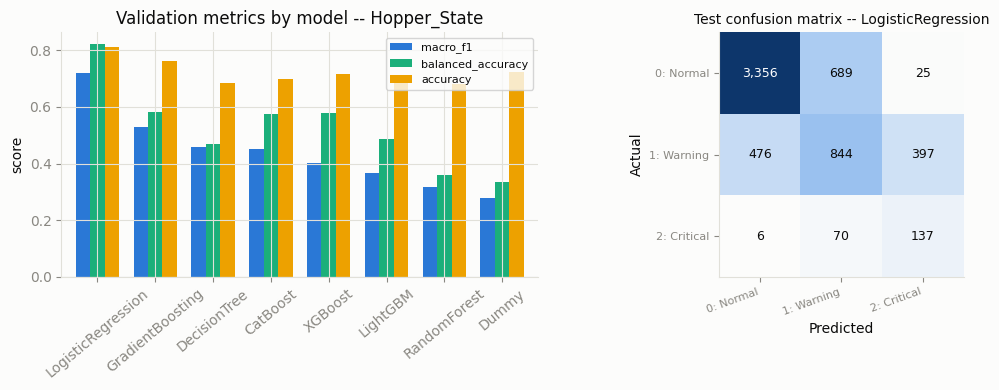

In [23]:
res = results["Hopper_State"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
val_plot = res["val_results"][["macro_f1", "balanced_accuracy", "accuracy"]]
val_plot.plot(kind="bar", ax=axes[0], color=[CAT_PALETTE[0], CAT_PALETTE[2], CAT_PALETTE[3]], width=0.75)
axes[0].set_title("Validation metrics by model -- Hopper_State")
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(fontsize=8)
axes[0].axhline(0, color=GRID, linewidth=0.8)

plot_confusion_matrix(res["confusion_matrix"], f"Test confusion matrix -- {res['best_model_name']}", ax=axes[1])
fig.tight_layout()
plt.show()

Notice the **Dummy baseline** already reaches a high *accuracy* (because it
just predicts "Normal" every time) but its macro F1 and balanced accuracy are
far lower than the real models — exactly the imbalance problem flagged in
Section 1. The selected model is chosen by macro F1 / balanced accuracy, not
by that misleadingly high accuracy number.

## 11. Run the same pipeline for the remaining 8 subsystem targets

Same function, same features, same encoding — looped over the other 8
targets. Each one is an independent 3-class problem, so each gets its own
model comparison, its own selected model, and its own confusion matrix.

In [24]:
remaining_targets = [t for t in TARGET_COLS if t != "Hopper_State"]
for t in remaining_targets:
    results[t] = run_pipeline_for_target(t, train_df, val_df, test_df)
    print()

===== Target: Barrel_Heater_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
GradientBoosting      0.9293             0.8035           0.6583        0.8035    0.6390
XGBoost               0.9282             0.7646           0.6796        0.7646    0.6337
CatBoost              0.9307             0.8055           0.6554        0.8055    0.6312
RandomForest          0.9303             0.6805           0.7046        0.6805    0.6252
DecisionTree          0.9138             0.7280           0.6000        0.7280    0.6189
LogisticRegression    0.9105             0.7877           0.5618        0.7877    0.5541
LightGBM              0.8965             0.5643           0.4481        0.5643    0.4255
Dummy                 0.8943             0.3333           0.2981        0.3333    0.3147

Selected model: GradientBoosting

Test-set metrics (reported once, for the selected m

===== Target: Screw_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.8830             0.8810           0.7500        0.8810    0.8017
RandomForest          0.8663             0.6670           0.7711        0.6670    0.7088
CatBoost              0.7598             0.6691           0.6517        0.6691    0.6410
DecisionTree          0.7022             0.7089           0.5989        0.7089    0.6243
GradientBoosting      0.6977             0.7049           0.5853        0.7049    0.6133
LightGBM              0.6627             0.6327           0.5987        0.6327    0.5937
XGBoost               0.6785             0.6494           0.5804        0.6494    0.5911
Dummy                 0.8035             0.3333           0.2678        0.3333    0.2970

Selected model: LogisticRegression

Test-set metrics (reported once, for the selected model o

===== Target: Injection_Unit_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.8483             0.8701           0.7219        0.8701    0.7718
GradientBoosting      0.8870             0.7499           0.7363        0.7499    0.6580
RandomForest          0.8698             0.6114           0.8304        0.6114    0.6339
DecisionTree          0.8512             0.6780           0.6311        0.6780    0.6281
CatBoost              0.8688             0.6589           0.8209        0.6589    0.5992
LightGBM              0.8673             0.6517           0.8704        0.6517    0.5890
XGBoost               0.8658             0.6646           0.7834        0.6646    0.5620
Dummy                 0.8398             0.3333           0.2799        0.3333    0.3043

Selected model: LogisticRegression

Test-set metrics (reported once, for the selecte

===== Target: Hydraulic_System_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.7535             0.8209           0.5478        0.8209    0.5992
RandomForest          0.9035             0.6178           0.5669        0.6178    0.5635
DecisionTree          0.7360             0.7096           0.5005        0.7096    0.5442
CatBoost              0.8830             0.6807           0.5120        0.6807    0.5389
GradientBoosting      0.8912             0.6808           0.5398        0.6808    0.5360
LightGBM              0.9088             0.6593           0.4654        0.6593    0.5308
XGBoost               0.9047             0.6507           0.4473        0.6507    0.5113
Dummy                 0.8930             0.3333           0.2977        0.3333    0.3145

Selected model: LogisticRegression

Test-set metrics (reported once, for the selec

===== Target: Clamp_Unit_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.8383             0.6171           0.7068        0.6171    0.6044
DecisionTree          0.8015             0.5318           0.4516        0.5318    0.4667
GradientBoosting      0.8490             0.4725           0.4532        0.4725    0.4620
XGBoost               0.8800             0.4321           0.4965        0.4321    0.4506
LightGBM              0.8368             0.4232           0.4241        0.4232    0.4235
CatBoost              0.8662             0.3941           0.4552        0.3941    0.4057
Dummy                 0.8575             0.3333           0.2858        0.3333    0.3078
RandomForest          0.8565             0.3329           0.2861        0.3329    0.3077

Selected model: LogisticRegression

Test-set metrics (reported once, for the selected mo

===== Target: Mold_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
GradientBoosting      0.8163             0.4512           0.6858        0.4512    0.4987
RandomForest          0.8437             0.4241           0.6351        0.4241    0.4548
DecisionTree          0.6485             0.4505           0.4194        0.4505    0.4246
LogisticRegression    0.7163             0.6143           0.4375        0.6143    0.4054
XGBoost               0.8147             0.3788           0.4065        0.3788    0.3836
CatBoost              0.7657             0.3639           0.3629        0.3639    0.3631
LightGBM              0.7498             0.3591           0.3550        0.3591    0.3570
Dummy                 0.8343             0.3333           0.2781        0.3333    0.3032

Selected model: GradientBoosting

Test-set metrics (reported once, for the selected model only

===== Target: Cooling_System_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
GradientBoosting      0.8032             0.4922           0.5230        0.4922    0.4845
LogisticRegression    0.6718             0.6142           0.5023        0.6142    0.4442
CatBoost              0.8012             0.4657           0.4342        0.4657    0.4267
XGBoost               0.7860             0.4072           0.5003        0.4072    0.4157
RandomForest          0.7968             0.3773           0.4109        0.3773    0.3674
DecisionTree          0.7475             0.3820           0.3023        0.3820    0.3275
LightGBM              0.7987             0.3349           0.5995        0.3349    0.2991
Dummy                 0.7985             0.3333           0.2662        0.3333    0.2960

Selected model: GradientBoosting

Test-set metrics (reported once, for the selected 

===== Target: Ejector_System_State =====

Validation-set comparison (sorted by macro F1, then balanced accuracy):
                    accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1
LogisticRegression    0.7908             0.7543           0.6856        0.7543    0.7088
CatBoost              0.7402             0.6161           0.6372        0.6161    0.5632
GradientBoosting      0.6992             0.6087           0.5605        0.6087    0.5061
DecisionTree          0.6473             0.5083           0.4916        0.5083    0.4989
RandomForest          0.7037             0.4300           0.6810        0.4300    0.4338
XGBoost               0.6913             0.5221           0.5619        0.5221    0.4236
LightGBM              0.6007             0.5110           0.5887        0.5110    0.3610
Dummy                 0.6745             0.3333           0.2248        0.3333    0.2685

Selected model: LogisticRegression

Test-set metrics (reported once, for the selecte

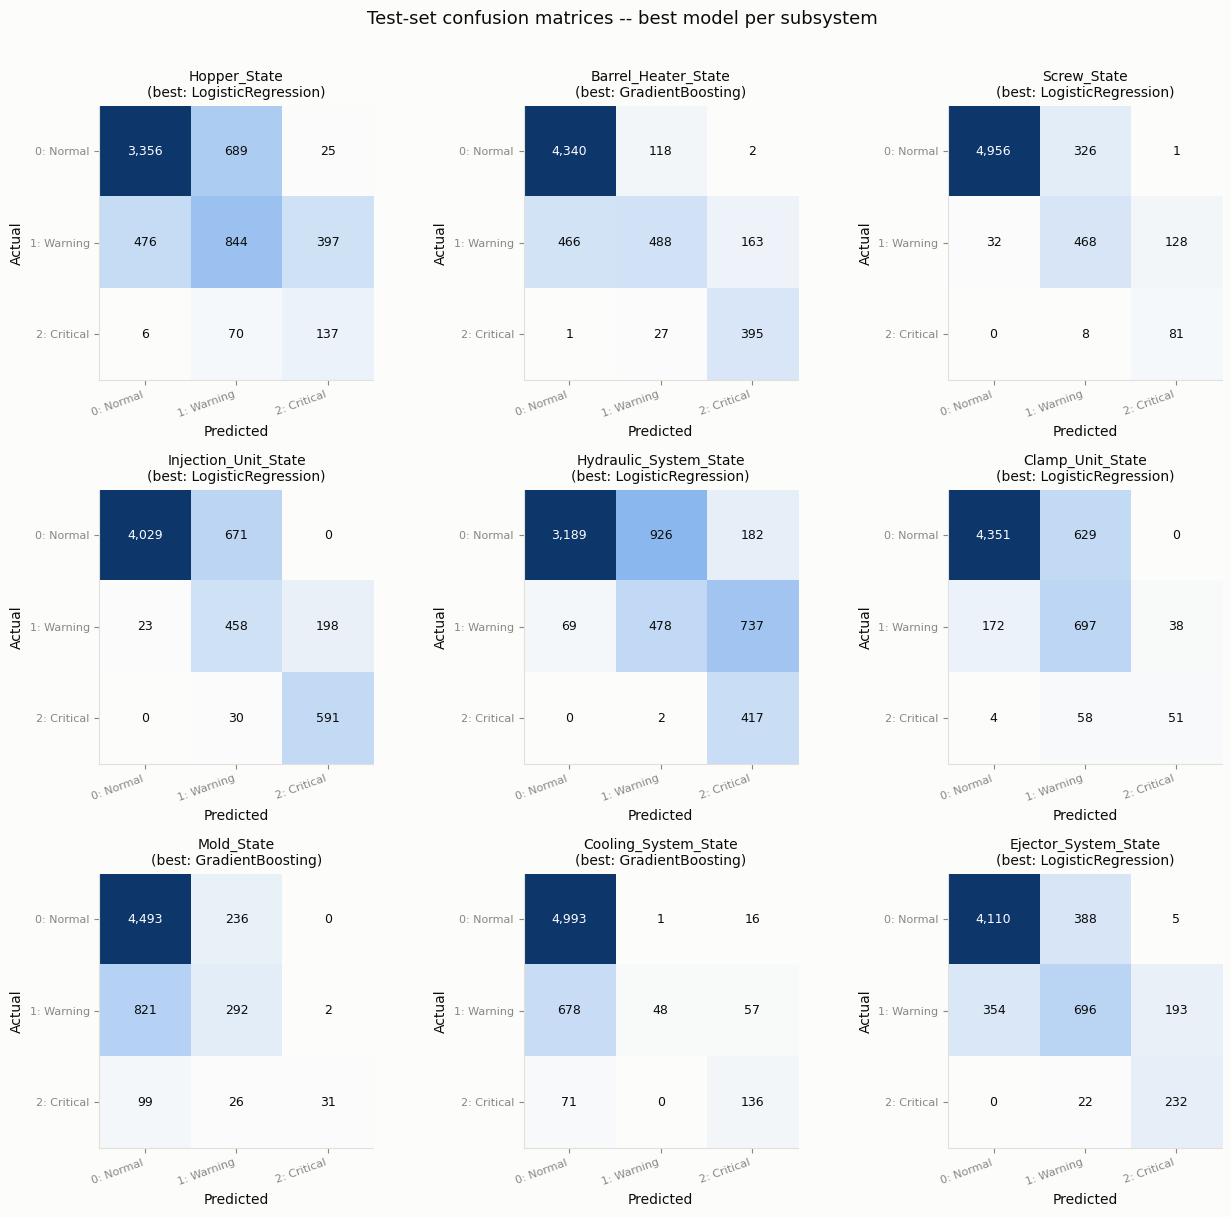

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for ax, t in zip(axes.flat, TARGET_COLS):
    plot_confusion_matrix(results[t]["confusion_matrix"], f"{t}\n(best: {results[t]['best_model_name']})", ax=ax)
fig.suptitle("Test-set confusion matrices -- best model per subsystem", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## 12. Final summary across all 9 subsystems

In [26]:
summary_rows = []
for t in TARGET_COLS:
    r = results[t]
    row = {"target": t, "best_model": r["best_model_name"]}
    row.update({f"test_{k}": v for k, v in r["test_metrics"].items()})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("target")
summary_df.round(4)

,best_model,test_accuracy,test_balanced_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
target,,,,,,
Hopper_State,LogisticRegression,0.7228,0.6531,0.5487,0.6531,0.5707
Barrel_Heater_State,GradientBoosting,0.8705,0.7813,0.7930,0.7813,0.7660
Screw_State,LogisticRegression,0.9175,0.8645,0.6543,0.8645,0.7205
Injection_Unit_State,LogisticRegression,0.8463,0.8278,0.7128,0.8278,0.7525
Hydraulic_System_State,LogisticRegression,0.6807,0.7032,0.5436,0.7032,0.5583
Clamp_Unit_State,LogisticRegression,0.8498,0.6978,0.6793,0.6978,0.6762
Mold_State,GradientBoosting,0.8027,0.4702,0.7655,0.4702,0.5213
Cooling_System_State,GradientBoosting,0.8628,0.5716,0.8333,0.5716,0.5660
Ejector_System_State,LogisticRegression,0.8397,0.7953,0.6965,0.7953,0.7292


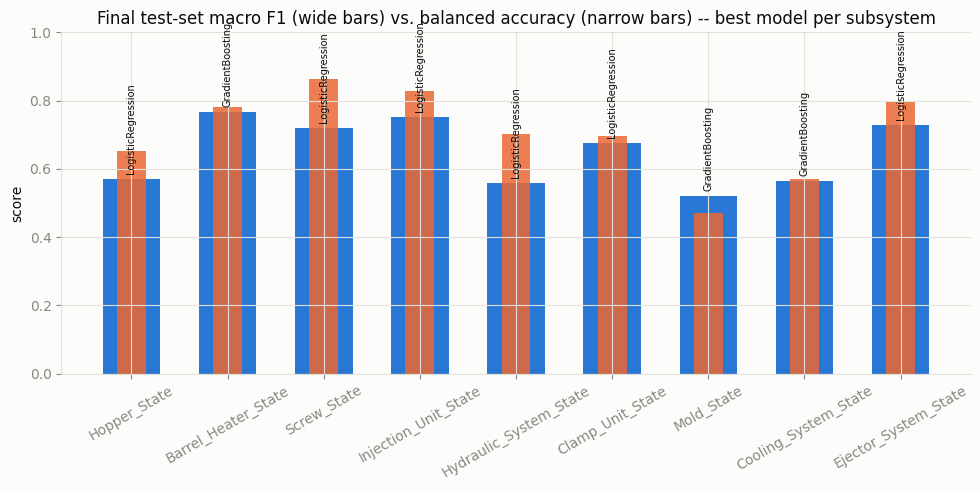


Which model won most often:
best_model
LogisticRegression    6
GradientBoosting      3
Name: count, dtype: int64


In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(summary_df.index, summary_df["test_macro_f1"], color=CAT_PALETTE[0], width=0.6)
ax.bar(summary_df.index, summary_df["test_balanced_accuracy"], color=CAT_PALETTE[1], width=0.3, alpha=0.85)
ax.set_ylabel("score")
ax.set_title("Final test-set macro F1 (wide bars) vs. balanced accuracy (narrow bars) -- best model per subsystem")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 1)
for b, name in zip(bars, summary_df["best_model"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, name, ha="center", fontsize=7, rotation=90)
fig.tight_layout()
plt.show()

print("\nWhich model won most often:")
print(summary_df["best_model"].value_counts())

## 13. Conclusions & next steps

- Every one of the 9 subsystem targets is heavily imbalanced toward
  "Normal" — reporting plain accuracy anywhere in this project would be
  misleading, which is why every comparison and every final number here is
  macro F1 / balanced accuracy / macro precision-recall, backed by a full
  confusion matrix.
- The gradient-boosted tree models (XGBoost / LightGBM / CatBoost /
  GradientBoosting) generally have the best chance of beating the simpler
  baselines because they can pick up non-linear interactions between process
  parameters and are less sensitive to the leftover feature correlation than
  Logistic Regression.
- The lag/rolling ("previous cycle", "recent rolling std") features were
  built specifically to give the models a *trend* signal, which is what a
  real predictive-maintenance alert needs — a single cycle rarely tells you a
  part is about to fail, but a drifting or destabilizing trend across recent
  cycles often does.
- **Natural next steps** for turning this into the full system described in
  the project brief: (1) inspect feature importances / SHAP values for the
  winning model per subsystem to make alerts explainable to a maintenance
  technician; (2) tune the alert decision threshold per subsystem based on
  the operational cost of a missed Critical vs. a false alarm, rather than
  using the default 0.5 argmax; (3) wire the selected models into the
  web-based monitoring application so each new cycle's reading produces a
  live health prediction per subsystem.

In [5]:
import pandas as pd

# Macro F1 scores for each target
data = {
    "Target": [
        "Barrel_Heater_State",
        "Screw_State",
        "Injection_Unit_State",
        "Hydraulic_System_State",
        "Clamp_Unit_State",
        "Mold_State",
        "Cooling_System_State",
        "Ejector_System_State"
    ],

    "GradientBoosting": [
        0.6390, 0.6133, 0.6580, 0.5360,
        0.4620, 0.4987, 0.4845, 0.5061
    ],

    "XGBoost": [
        0.6337, 0.5911, 0.5620, 0.5113,
        0.4506, 0.3836, 0.4157, 0.4236
    ],

    "CatBoost": [
        0.6312, 0.6410, 0.5992, 0.5389,
        0.4057, 0.3631, 0.4267, 0.5632
    ],

    "RandomForest": [
        0.6252, 0.7088, 0.6339, 0.5635,
        0.3077, 0.4548, 0.3674, 0.4338
    ],

    "DecisionTree": [
        0.6189, 0.6243, 0.6281, 0.5442,
        0.4667, 0.4246, 0.3275, 0.4989
    ],

    "LogisticRegression": [
        0.5541, 0.8017, 0.7718, 0.5992,
        0.6044, 0.4054, 0.4442, 0.7088
    ],

    "LightGBM": [
        0.4255, 0.5937, 0.5890, 0.5308,
        0.4235, 0.3570, 0.2991, 0.3610
    ],

    "Dummy": [
        0.3147, 0.2970, 0.3043, 0.3145,
        0.3078, 0.3032, 0.2960, 0.2685
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Macro F1 DataFrame:")
print(df)

# Calculate average Macro F1 for each model
average_f1 = df.drop(columns="Target").mean().sort_values(ascending=False)

# Convert to DataFrame
average_f1_df = average_f1.reset_index()
average_f1_df.columns = ["Model", "Average_Macro_F1"]

print("\nAverage Macro F1:")
print(average_f1_df)

Macro F1 DataFrame:
                   Target  GradientBoosting  XGBoost  CatBoost  RandomForest  \
0     Barrel_Heater_State            0.6390   0.6337    0.6312        0.6252   
1             Screw_State            0.6133   0.5911    0.6410        0.7088   
2    Injection_Unit_State            0.6580   0.5620    0.5992        0.6339   
3  Hydraulic_System_State            0.5360   0.5113    0.5389        0.5635   
4        Clamp_Unit_State            0.4620   0.4506    0.4057        0.3077   
5              Mold_State            0.4987   0.3836    0.3631        0.4548   
6    Cooling_System_State            0.4845   0.4157    0.4267        0.3674   
7    Ejector_System_State            0.5061   0.4236    0.5632        0.4338   

   DecisionTree  LogisticRegression  LightGBM   Dummy  
0        0.6189              0.5541    0.4255  0.3147  
1        0.6243              0.8017    0.5937  0.2970  
2        0.6281              0.7718    0.5890  0.3043  
3        0.5442              0.5992

In [6]:
df.drop(columns="Target").mean().sort_values(ascending=False)

LogisticRegression    0.611200
GradientBoosting      0.549700
CatBoost              0.521125
DecisionTree          0.516650
RandomForest          0.511888
XGBoost               0.496450
LightGBM              0.447450
Dummy                 0.300750
dtype: float64